Stratified K-Fold

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.datasets import load_iris
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Species")

df = X.copy()
df["species"] = y
display(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [4]:
model = LogisticRegression(solver="lbfgs", random_state=42)

In [5]:
K = 10

In [13]:
acc_standard = []
kf_standard = KFold(n_splits=K, shuffle=True, random_state=42)

for train_index, test_index in kf_standard.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    acc_standard.append(score)

In [14]:
acc_stratified = []

kf_stratified = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

for train_index, test_index in kf_stratified.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    acc_stratified.append(score)

In [16]:
mean_standard = np.mean(acc_standard)
std_standard = np.std(acc_standard)
mean_stratified = np.mean(acc_stratified)
std_stratified = np.std(acc_stratified)

print(f"K-Fold Standard:\n\tMedia:\t{mean_standard:.4f}\n\tstd:\t{std_standard:.4f}\n\tAccuracy:\t{np.round(acc_standard, 4)}")
print(f"K-Fold Stratified:\n\tMedia:\t{mean_stratified:.4f}\n\tstd:\t{std_stratified:.4f}\n\tAccuracy:\t{np.round(acc_stratified, 4)}")

K-Fold Standard:
	Media:	0.9533
	std:	0.0670
	Accuracy:	[1.     1.     1.     0.9333 1.     0.8667 0.8    1.     1.     0.9333]
K-Fold Stratified:
	Media:	0.9533
	std:	0.0521
	Accuracy:	[1.     1.     1.     0.9333 0.8667 0.9333 1.     1.     0.9333 0.8667]


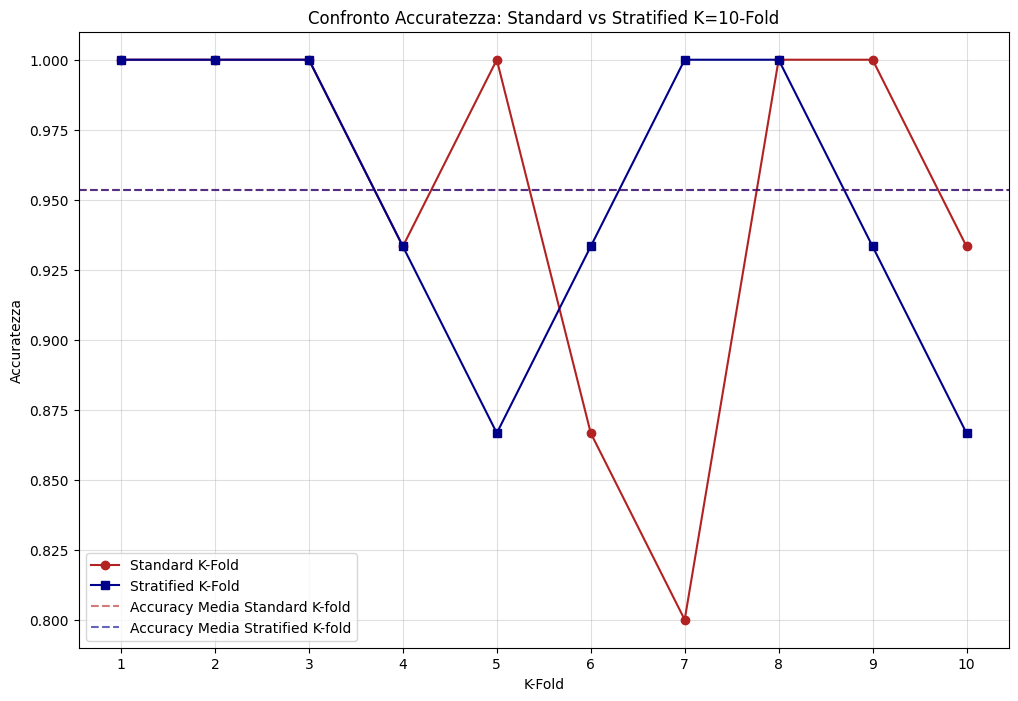

In [18]:
plt.figure(figsize=(12,8))

plt.plot(np.arange(1, K+1), acc_standard, marker="o", linestyle="-", color="firebrick", label="Standard K-Fold")
plt.plot(np.arange(1, K+1), acc_stratified, marker="s", linestyle="-", color="darkblue", label="Stratified K-Fold")

plt.axhline(mean_standard, color="firebrick", linestyle="--", alpha=0.6, label="Accuracy Media Standard K-fold")
plt.axhline(mean_stratified, color="darkblue", linestyle="--", alpha=0.6, label="Accuracy Media Stratified K-fold")

plt.xticks(range(1, K+1))

plt.title(f"Confronto Accuratezza: Standard vs Stratified K={K}-Fold")
plt.xlabel("K-Fold")
plt.ylabel("Accuratezza")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()